# Объединим датасеты

Мы получили датасет путем скрапинга и по апи. Теперь соединим их таким образом, чтобы объявление находилось сразу в обоих датасетах


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_api = pd.read_csv('new_data.csv')
df_skraping = pd.read_csv('checkpoint_4400.csv')

In [ ]:
df_api.head(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,overall_rating,front_crash_rating,side_crash_rating,rollover_rating,manufacturer_country,model_exists
0,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,222,15,2,6,20,4,4,4,4,MEXICO,True
1,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,toyota,camry,2019,6,361,18,0,1,21,5,5,5,5,UNITED STATES (USA),True
2,https://auto.drom.ru/kovrov/hyundai/accent/441...,hyundai,accent,2007,3,88,19,0,1,11,Not Rated,Not Rated,Not Rated,Not Rated,MEXICO,True


In [ ]:
df_api.shape

(1467, 16)

In [ ]:
df_skraping.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,"Продажа Toyota Crown, 1990 год в Екатеринбурге",1990.0,ekaterinburg,toyota,crown,500000.0,"бензин, 2.0 л",АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,"Продажа Hyundai Elantra, 2020 год в Перми",2020.0,perm,hyundai,elantra,689000.0,"бензин, 2.0 л",АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,"Продажа Toyota Camry, 2019 год во Всеволожске",2019.0,vsevolozhsk,toyota,camry,1600000.0,"бензин, 2.0 л",АКПП,400000.0,передний,седан,белый,левый,150.0,: Машина ходовое вложение не требует Город : В...


In [ ]:
df_skraping.shape

(4398, 16)

In [ ]:
df = pd.merge(df_api, df_skraping, on = ['url', 'make', 'model', 'year'], how = 'inner')

In [ ]:
df.shape

(1467, 28)

In [ ]:
df.sample(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
285,https://auto.drom.ru/novocherkassk/kia/rio/440...,kia,rio,2015,1,52,11,0,10,4,...,999000.0,"бензин, 1.6 л",АКПП,144322.0,передний,седан,черный,левый,123.0,": Пpиветствуeм Вaс в cети автосaлонoв ""АBТОЛEВ..."
1289,https://auto.drom.ru/omsk/mazda/mazda3/5731003...,mazda,mazda3,2007,3,222,28,0,3,28,...,545000.0,"бензин, 1.6 л",АКПП,231700.0,передний,седан,красный,левый,105.0,: 🌐 Автосалон “Звезда Сибири ” 🔴Режим работы 🕘...
1174,https://auto.drom.ru/krasnodar/bmw/x6/54595696...,bmw,x6,2010,9,19,3,0,4,0,...,1700000.0,"бензин, 4.4 л",АКПП,235000.0,4WD,NaN,черный,левый,555.0,: Продам живую не отжатую мку с родным не скру...


In [ ]:
df.dtypes

,0
url,object
make,object
model,object
year,int64
recalls_count,int64
complaints_count,int64
injuries,int64
deaths,int64
has_fire,int64
has_crash,int64


Давайте приведем все к корректным типам данных. В целом, почти все типы данных корректны, только в столбцах, связанных с рейтингом должен быть float, а не object. Такое возникает потому что пропуск прописывается фразой 'Not Rated'. Давайте все такие значения заменим на Nan

In [ ]:
print('Количество Not Rated в overall_rating', (df['overall_rating'] == 'Not Rated').sum())
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Not Rated в front_crash_rating', (df['front_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Not Rated в side_crash_rating', (df['side_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Not Rated в rollover_rating', (df['rollover_rating'] == 'Not Rated').sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Not Rated в overall_rating 785
Количество Nan в overall_rating 87
Количество Not Rated в front_crash_rating 781
Количество Nan в front_crash_rating 87
Количество Not Rated в side_crash_rating 782
Количество Nan в side_crash_rating 87
Количество Not Rated в rollover_rating 583
Количество Nan в rollover_rating 87


In [ ]:
df.loc[df['overall_rating'] == 'Not Rated', 'overall_rating'] = np.nan
df.loc[df['front_crash_rating'] == 'Not Rated', 'front_crash_rating'] = np.nan
df.loc[df['side_crash_rating'] == 'Not Rated', 'side_crash_rating'] = np.nan
df.loc[df['rollover_rating'] == 'Not Rated', 'rollover_rating'] = np.nan

In [ ]:
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Nan в overall_rating 872
Количество Nan в front_crash_rating 868
Количество Nan в side_crash_rating 869
Количество Nan в rollover_rating 670


In [ ]:
df['overall_rating'] = pd.to_numeric(df['overall_rating'])
df['front_crash_rating'] = pd.to_numeric(df['front_crash_rating'])
df['side_crash_rating'] = pd.to_numeric(df['side_crash_rating'])
df['rollover_rating'] = pd.to_numeric(df['rollover_rating'])

Поменяли на Nan, видим, что очень большое количество пропусков в этих столбцах, но к пропускам вернемся позже, нашей задачей было привести все к корректным типам

In [ ]:
df.dtypes

,0
url,object
make,object
model,object
year,int64
recalls_count,int64
complaints_count,int64
injuries,int64
deaths,int64
has_fire,int64
has_crash,int64


Вот теперь все супер! Все столбцы имеют корректные типы данных

# Перейдем к анализу признаков на целевую переменную

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Марка авто

In [ ]:
median_make = pd.pivot_table(df,values='price', index='make', aggfunc='median')
median_make

,price
make,
bmw,2650000.0
ford,620000.0
honda,890000.0
hyundai,850000.0
kia,1295000.0
mazda,900000.0
mitsubishi,750000.0
nissan,1065000.0
toyota,1400000.0


Text(0, 0.5, 'Медианная цена')

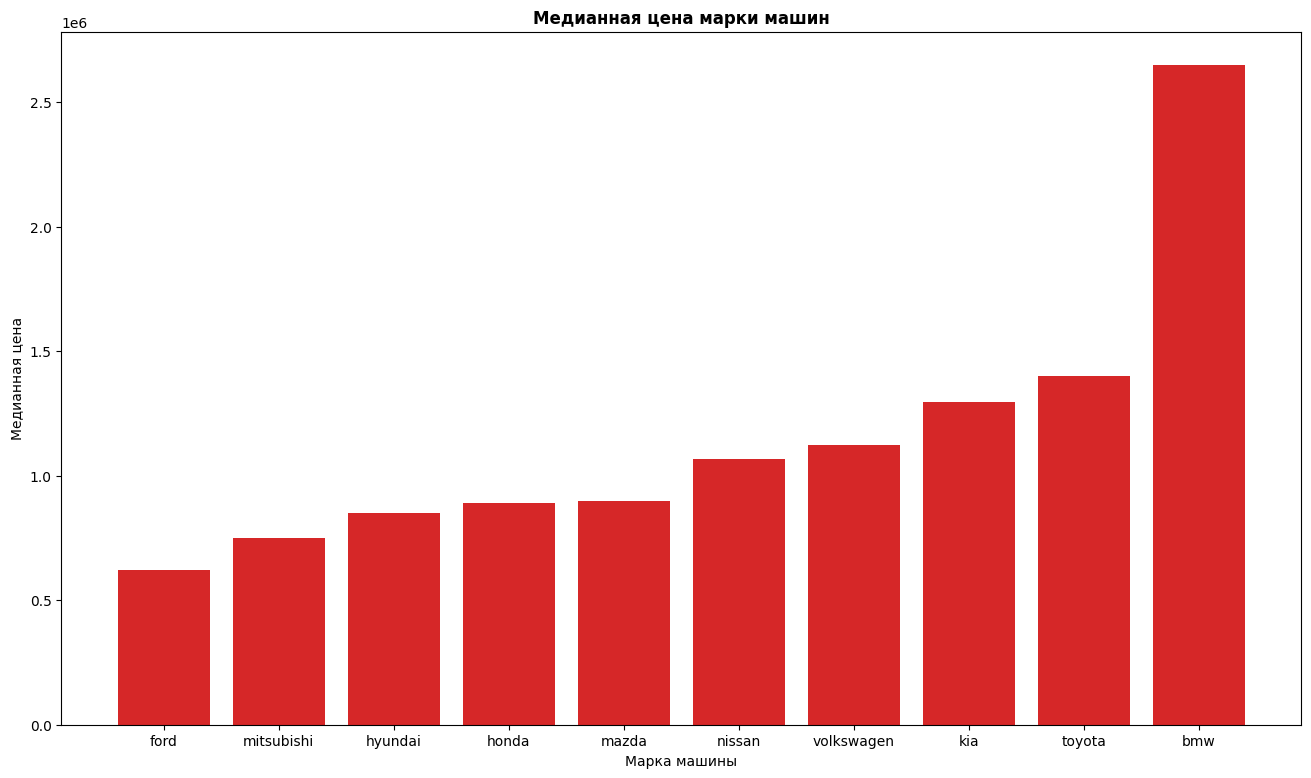

In [ ]:
median_make = median_make.sort_values(by='price')
plt.figure(figsize=(16, 9))
plt.bar(median_make.index, median_make['price'], color = '#D62728')

plt.title("Медианная цена марки машин",fontweight='bold')
plt.xlabel('Марка машины')
plt.ylabel('Медианная цена')

**какой-то вывод**

#Цвет авто

In [ ]:
median_clr = pd.pivot_table(df,values='price', index='color', aggfunc='median')
median_clr

,price
color,
бежевый,930000.0
белый,1500000.0
бордовый,567500.0
голубой,415000.0
желтый,940000.0
зеленый,530000.0
золотистый,1450000.0
коричневый,1680000.0
красный,750000.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'голубой'),
  Text(1, 0, 'зеленый'),
  Text(2, 0, 'бордовый'),
  Text(3, 0, 'фиолетовый'),
  Text(4, 0, 'оранжевый'),
  Text(5, 0, 'серебристый'),
  Text(6, 0, 'розовый'),
  Text(7, 0, 'красный'),
  Text(8, 0, 'синий'),
  Text(9, 0, 'бежевый'),
  Text(10, 0, 'желтый'),
  Text(11, 0, 'серый'),
  Text(12, 0, 'черный'),
  Text(13, 0, 'золотистый'),
  Text(14, 0, 'белый'),
  Text(15, 0, 'коричневый')])

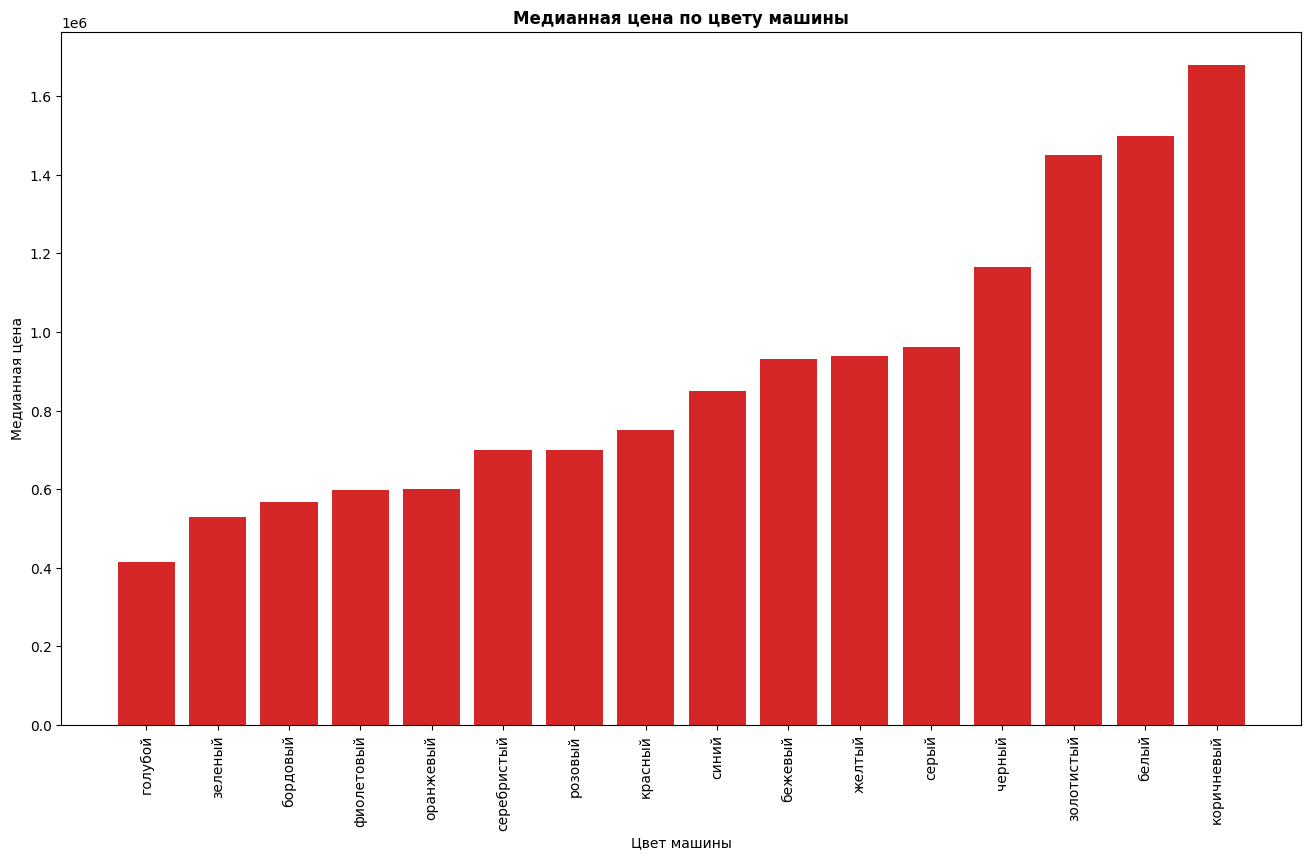

In [ ]:
median_clr = median_clr.sort_values(by='price')
plt.figure(figsize=(16, 9))
plt.bar(median_clr.index, median_clr['price'], color = '#D62728')

plt.title("Медианная цена по цвету машины",fontweight='bold')
plt.xlabel('Цвет машины')
plt.ylabel('Медианная цена')
plt.xticks(rotation=90)

**ВЫввод**

#Год выпуска

In [ ]:
df['year'].value_counts().sort_values()

,count
year,
1983,1
1990,1
1987,1
1991,3
1993,3
1989,3
1992,3
1994,5
2026,5


In [ ]:
less_2005 = [1983, 1987, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005]


from_2006_to_2010 = [2006, 2007, 2008,2009,2010]

from_2011_to_2016 = [2011, 2012, 2013, 2014, 2015, 2016]

from_2017_to_2026 = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

df.loc[df['year'].isin(less_2005), 'car_year'] = '< 2005'
df.loc[df['year'].isin(from_2006_to_2010), 'car_year'] = '2006 - 2010'
df.loc[df['year'].isin(from_2011_to_2016), 'car_year'] = '2011 - 2016'
df.loc[df['year'].isin(from_2017_to_2026), 'car_year'] = '2017 - 2026'

In [ ]:
year_category_pivot = pd.pivot_table(df, values = 'price', index = 'car_year', aggfunc = 'median')

year_category_pivot

,price
car_year,
2006 - 2010,665000.0
2011 - 2016,1197400.0
2017 - 2026,2400000.0
< 2005,360000.0


In [ ]:
order = ['< 2005', '2006 - 2010', '2011 - 2016', '2017 - 2026']
year_category_pivot = year_category_pivot.reindex(order)

Text(0, 0.5, 'Медианная цена')

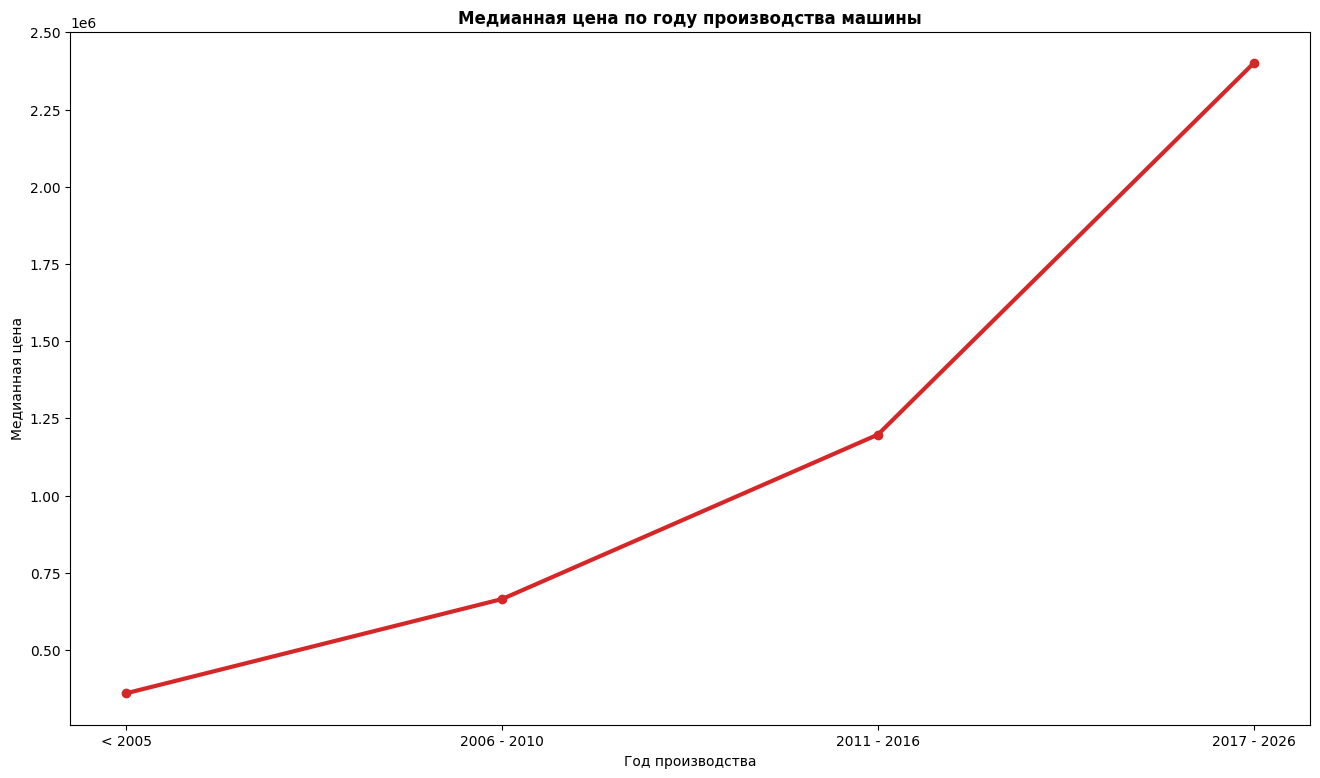

In [ ]:
plt.figure(figsize=(16, 9))
plt.plot(year_category_pivot.index, year_category_pivot['price'], color = '#D62728', marker='o',linewidth=3 )

plt.title("Медианная цена по году производства машины",fontweight='bold')
plt.xlabel('Год производства')
plt.ylabel('Медианная цена')


**опять вывод**

#Город обьявления

In [ ]:
df['city'].value_counts()

,count
city,
moscow,183
novosibirsk,69
spb,69
ekaterinburg,45
tyumen,44
...,...
vladimir,1
bolshoy-uluy,1
anzhero-sudzhensk,1


Для того, чтобы однозначно определить, влияет ли город на цену, посмотрим на модель и марку автомобиля, так как это нам позволит провести анализ на уровне конкретного автомобиля

In [ ]:
df['marka_s_model'] = df['make'] + ' ' + df['model']
df['marka_s_model']

,marka_s_model
0,hyundai elantra
1,toyota camry
2,hyundai accent
3,hyundai accent
4,hyundai elantra
...,...
1462,mitsubishi outlander
1463,mitsubishi mirage
1464,mitsubishi outlander
1465,mitsubishi outlander


In [ ]:
popular_marka = df['marka_s_model'].value_counts().head(5)
popular_marka

,count
marka_s_model,
ford focus,177
kia rio,86
mitsubishi lancer,74
mitsubishi outlander,70
mazda mazda3,70


In [ ]:
popular_city = df['city'].value_counts().head(5)
popular_city

,count
city,
moscow,183
novosibirsk,69
spb,69
ekaterinburg,45
tyumen,44


In [ ]:
top_c_and_mm = df[(df['city'].isin(popular_city.index)) & (df['marka_s_model'].isin(popular_marka.index))]
top_c_and_mm

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,transmission,mileage,drive,body,color,wheel,hp,description,car_year,marka_s_model
15,https://auto.drom.ru/moscow/kia/rio/798384036....,kia,rio,2002,1,158,32,1,10,29,...,АКПП,170788.0,передний,универсал,синий,левый,95.0,: здравствуйте продаю авто машинка на ходу мат...,< 2005,kia rio
67,https://auto.drom.ru/moscow/kia/rio/811101207....,kia,rio,2018,1,26,1,0,2,3,...,АКПП,99000.0,передний,седан,красный,левый,123.0,: Киа рио 4 2018 год в отличном состоянии . во...,2017 - 2026,kia rio
88,https://auto.drom.ru/moscow/kia/rio/190274161....,kia,rio,2012,1,50,4,0,9,3,...,АКПП,NaN,передний,седан,NaN,левый,107.0,: KIA RIO 2012 1.4 АТ ✅движок работает идеальн...,2011 - 2016,kia rio
101,https://auto.drom.ru/spb/kia/rio/569664425.html,kia,rio,2010,0,26,8,0,0,9,...,АКПП,193600.0,передний,седан,черный,левый,95.0,: Модель: Rio Комплектация: Comfort Этот автом...,2006 - 2010,kia rio
129,https://auto.drom.ru/moscow/kia/rio/641729006....,kia,rio,2013,1,152,8,0,17,8,...,АКПП,216000.0,передний,седан,белый,левый,123.0,": В хорошем состоянии и на отличном ходу, авто...",2011 - 2016,kia rio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,https://auto.drom.ru/moscow/mitsubishi/outland...,mitsubishi,outlander,2020,2,27,7,0,0,5,...,вариатор,130000.0,передний,NaN,белый,левый,146.0,NaN,2017 - 2026,mitsubishi outlander
1457,https://auto.drom.ru/novosibirsk/mitsubishi/ou...,mitsubishi,outlander,2012,6,36,2,1,0,4,...,вариатор,145500.0,4WD,NaN,серый,левый,146.0,: Я собственник. Японская сборка! Покупался и ...,2011 - 2016,mitsubishi outlander
1459,https://auto.drom.ru/moscow/mitsubishi/lancer/...,mitsubishi,lancer,2005,6,24,2,0,0,3,...,механика,100000.0,передний,седан,NaN,левый,98.0,: В продаже Mitsubishi Lancer 9 рестайлинг 1.6...,< 2005,mitsubishi lancer
1460,https://auto.drom.ru/moscow/mitsubishi/lancer/...,mitsubishi,lancer,2006,7,37,3,0,0,5,...,механика,199340.0,передний,седан,синий,левый,82.0,: Продам автомобиль в хорошем состоянии.Своевр...,2006 - 2010,mitsubishi lancer


In [ ]:
city_pivot = pd.pivot_table(top_c_and_mm, values='price',index='city',columns='marka_s_model',aggfunc='median')
city_pivot

marka_s_model,ford focus,kia rio,mazda mazda3,mitsubishi lancer,mitsubishi outlander
city,,,,,
ekaterinburg,465000.0,NaN,715000.0,310000.0,1269000.0
moscow,899000.0,735000.0,500000.0,270000.0,1359500.0
novosibirsk,535000.0,790000.0,670000.0,732500.0,1952500.0
spb,629500.0,810000.0,490000.0,595000.0,749990.0
tyumen,574500.0,962500.0,310000.0,NaN,1690000.0


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'ekaterinburg'),
  Text(1, 0, 'moscow'),
  Text(2, 0, 'novosibirsk'),
  Text(3, 0, 'spb'),
  Text(4, 0, 'tyumen')])

<Figure size 1600x900 with 0 Axes>

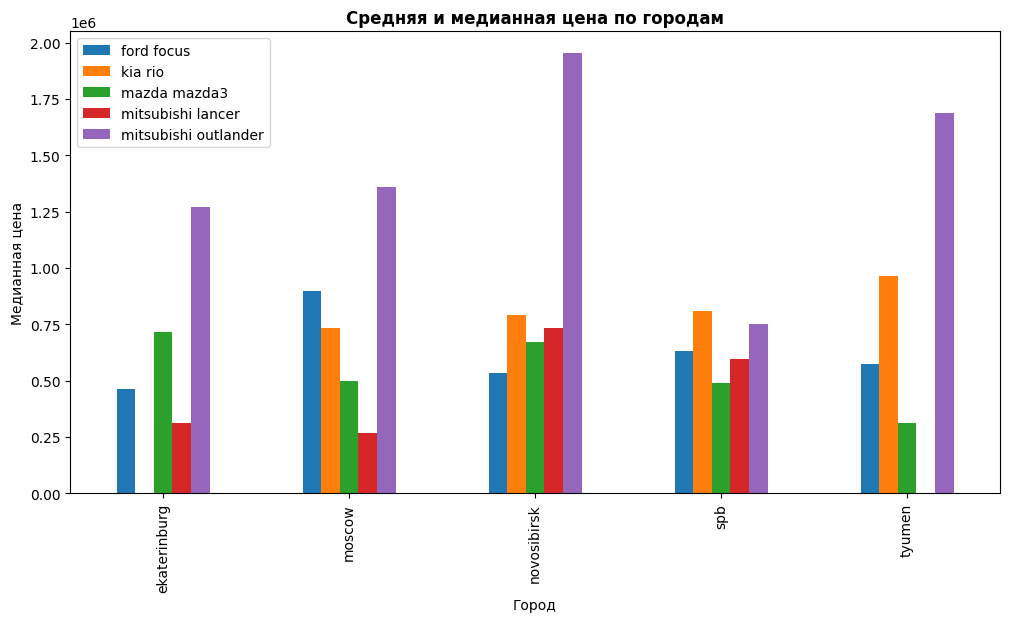

In [ ]:
plt.figure(figsize=(16, 9))
city_pivot.plot(kind='bar', figsize=(12, 6))


plt.title("Средняя и медианная цена по городам",fontweight='bold')
plt.xlabel('Город')
plt.ylabel('Медианная цена')
plt.legend()
plt.xticks(rotation=90)

**снова вывод**

#probeg!!! доделать

In [ ]:
df['mileage'].unique()

array([8.80000e+04, 4.00000e+05, 2.38000e+05,         nan, 2.79123e+05,
       1.22000e+05, 8.00000e+01, 1.66879e+05, 1.60375e+05, 1.11800e+04,
       1.62000e+05, 1.34953e+05, 8.71650e+04, 2.90000e+05, 1.70788e+05,
       1.97350e+05, 9.00000e+04, 2.45000e+05, 1.40000e+05, 6.67710e+04,
       1.77687e+05, 4.48000e+05, 2.23152e+05, 1.99000e+05, 3.65000e+05,
       1.21343e+05, 7.95000e+04, 1.84000e+05, 1.38250e+05, 8.00730e+04,
       7.58130e+04, 9.90000e+04, 2.15000e+05, 1.61903e+05, 1.21500e+05,
       2.70000e+05, 1.66000e+05, 6.70000e+04, 1.15000e+05, 2.65043e+05,
       3.11000e+05, 4.77600e+05, 3.33333e+05, 1.91000e+05, 8.17410e+04,
       1.80000e+05, 1.34837e+05, 3.50000e+02, 2.60000e+05, 2.05000e+05,
       3.50000e+05, 1.40000e+04, 2.92000e+05, 4.32600e+05, 1.26000e+05,
       6.81260e+04, 3.00000e+04, 1.75583e+05, 2.20671e+05, 2.65000e+05,
       1.18000e+05, 2.06000e+05, 1.00000e+03, 1.85000e+05, 1.41000e+05,
       2.40000e+05, 3.16800e+05, 2.07000e+05, 1.54580e+05, 2.750

**00 должно быть, где нан**

In [ ]:
df['mileage_cat'] = pd.cut(df['mileage'], bins=[0, 50000, 100000, 150000, 200000, 300000, 1000000],labels = ['0-50','50-100','100-150','150-200','200-300','300+'])

In [ ]:
mileage_pivot = pd.pivot_table(df, values='price',index='mileage_cat',aggfunc='median')
mileage_pivot

/tmp/ipykernel_9282/1538496504.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mileage_pivot = pd.pivot_table(df, values='price',index='mileage_cat',aggfunc='median')


,price
mileage_cat,
0-50,2855000.0
50-100,2160000.0
100-150,1360000.0
150-200,993500.0
200-300,715000.0
300+,475000.0


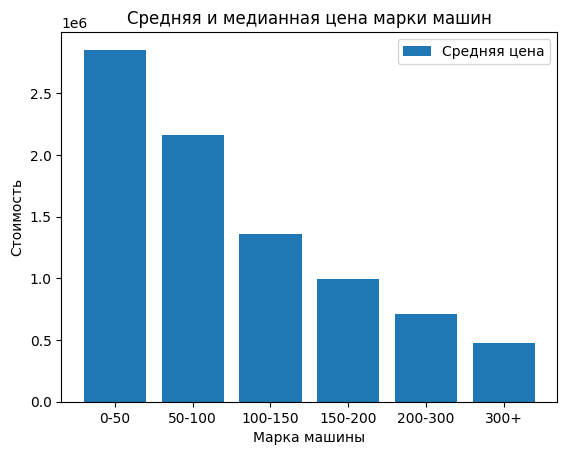

In [ ]:
plt.figure(figsize=(16, 9))
plt.bar(mileage_pivot.index, mileage_pivot['price'])


plt.title("Средняя и медианная цена марки машин")
plt.xlabel('Марка машины')
plt.ylabel('Стоимость')
plt.legend(['Средняя цена'])

#Кузов

In [ ]:
df['body'].value_counts()

,count
body,
седан,607
хэтчбек 5 дв.,164
джип/suv 5 дв.,104
универсал,53
лифтбек,10
хэтчбек 3 дв.,7
купе,7
открытый,2


In [ ]:
body_pivot = pd.pivot_table(df, values='price',index='body',aggfunc='median')
body_pivot

,price
body,
джип/suv 5 дв.,1824500.0
купе,3340000.0
лифтбек,720000.0
открытый,9265000.0
седан,707000.0
универсал,535000.0
хэтчбек 3 дв.,300000.0
хэтчбек 5 дв.,655000.0


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'джип/suv 5 дв.'),
  Text(1, 0, 'купе'),
  Text(2, 0, 'лифтбек'),
  Text(3, 0, 'открытый'),
  Text(4, 0, 'седан'),
  Text(5, 0, 'универсал'),
  Text(6, 0, 'хэтчбек 3 дв.'),
  Text(7, 0, 'хэтчбек 5 дв.')])

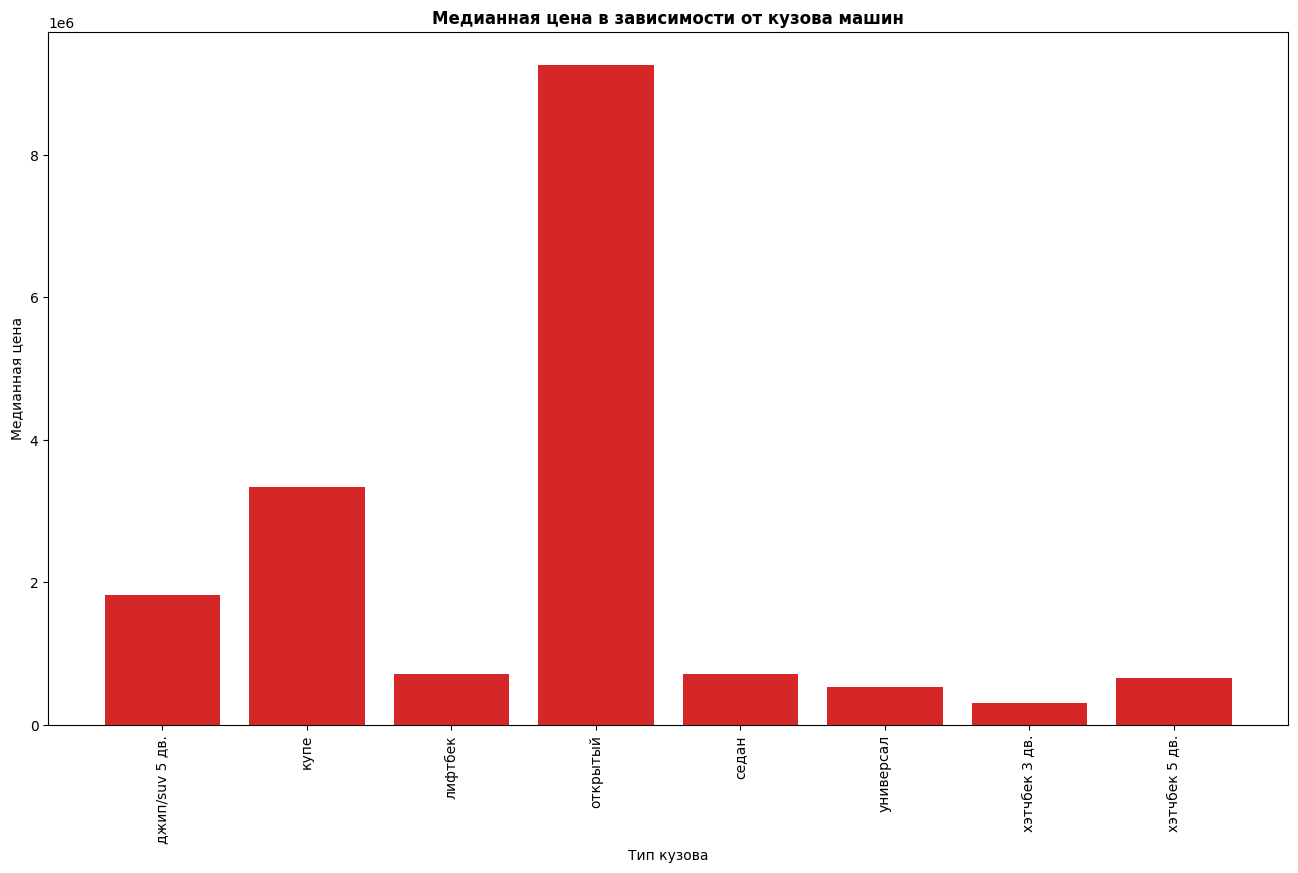

In [ ]:
plt.figure(figsize=(16, 9))
plt.bar(body_pivot.index, body_pivot['price'], color = '#D62728')


plt.title("Медианная цена в зависимости от кузова машин", fontweight='bold')
plt.xlabel('Тип кузова')
plt.ylabel('Медианная цена')
plt.xticks(rotation=90)

**VYVOODD**

#Руль

In [ ]:
wheel_pivot = pd.pivot_table(df, values='price',index='wheel',aggfunc='median')
wheel_pivot

,price
wheel,
левый,1000000.0
правый,710000.0


Text(0, 0.5, 'Медианная цена')

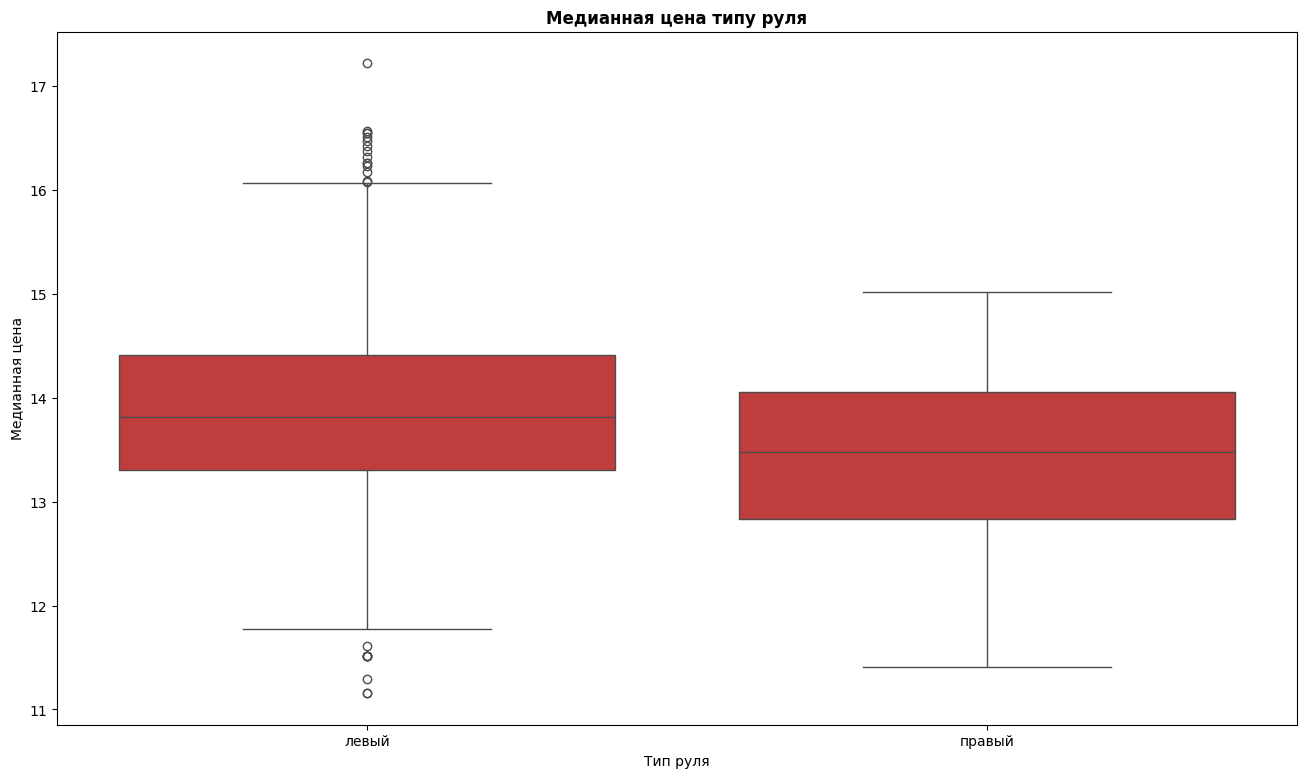

In [ ]:
plt.figure(figsize=(16, 9))
sns.boxplot(data=df,x='wheel',y=np.log(df['price']),color = '#D62728')

plt.title("Медианная цена типу руля",fontweight='bold')
plt.xlabel('Тип руля')
plt.ylabel('Медианная цена')

обьяснить почему логарифмируем и нужно ли это будет в итоговом датасете??????

#!!!engine - доделааать

In [ ]:
engine_pivot = pd.pivot_table(df, values='price',index='engine',aggfunc='median')
engine_pivot

,price
engine,
1.8 л,120000.0
2.0 л,1550000.0
"бензин, 1.0 л",682500.0
"бензин, 1.2 л",1215000.0
"бензин, 1.3 л",700000.0
"бензин, 1.3 л, ГБО",450000.0
"бензин, 1.3 л, гибрид",720000.0
"бензин, 1.4 л",899000.0
"бензин, 1.4 л, ГБО",840000.0


In [ ]:
df['engine'] = df['engine'].astype(str).str.lower()
df['engine']

,engine
0,"бензин, 2.0 л"
1,"бензин, 2.0 л"
2,"бензин, 1.5 л"
3,"бензин, 1.5 л"
4,"бензин, 1.6 л"
...,...
1462,"бензин, 2.0 л"
1463,"бензин, 1.0 л"
1464,"бензин, 3.0 л"
1465,"бензин, 2.0 л, гбо"


In [ ]:
df['engine'] = df['engine'].str.split(', ')
df['engine']

,engine
0,"[бензин, 2.0 л]"
1,"[бензин, 2.0 л]"
2,"[бензин, 1.5 л]"
3,"[бензин, 1.5 л]"
4,"[бензин, 1.6 л]"
...,...
1462,"[бензин, 2.0 л]"
1463,"[бензин, 1.0 л]"
1464,"[бензин, 3.0 л]"
1465,"[бензин, 2.0 л, гбо]"


In [ ]:
df['type_engine'] = df['engine'].str[0]
df['type_engine']

,type_engine
0,бензин
1,бензин
2,бензин
3,бензин
4,бензин
...,...
1462,бензин
1463,бензин
1464,бензин
1465,бензин


доделать

# !!!privod доделать, после фулл еда

In [ ]:
df['drive'].value_counts()

,count
drive,
передний,1022
4WD,430
задний,14


In [ ]:
drive_pivot = pd.pivot_table(df, values='price',index='drive',aggfunc='median')
drive_pivot

,price
drive,
4WD,1724500.0
задний,2800000.0
передний,779000.0


<Axes: xlabel='drive', ylabel='price'>

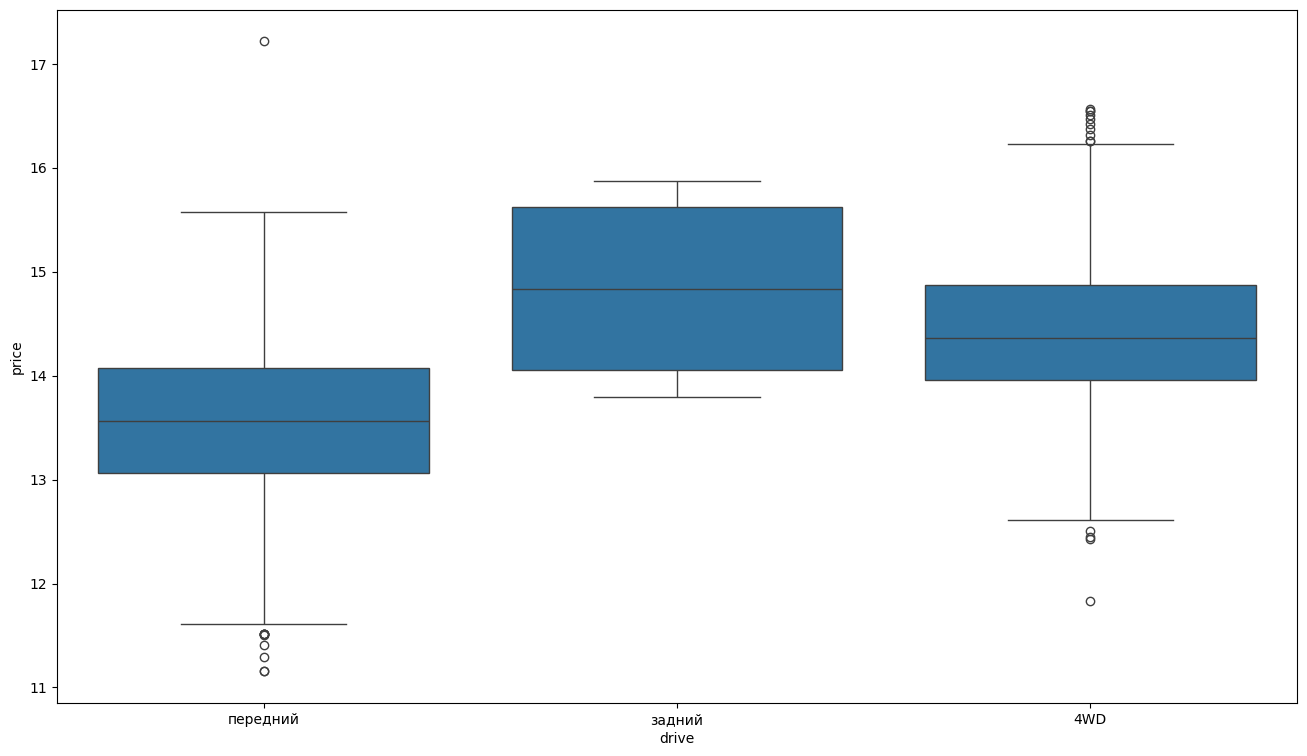

In [ ]:
plt.figure(figsize=(16, 9))
sns.boxplot(data=df,x='drive',y=np.log(df['price']))


#Лошадиные силы

In [ ]:
hp_cnt = df['hp'].value_counts().sort_values().count()
chp = hp_cnt[hp_cnt == 1]
chp.sum()

np.int64(0)

In [ ]:
df_hp = df[df.duplicated('hp', keep=False)]

In [ ]:
df_hp['hp'].unique()

array([150., 102., 105., 250., 181., 132., 200., 249., 146., 107., 100.,
        95., 101., 123., 175., 152., 180., 109., 182., 167., 188.,  97.,
       171., 115., 110., 184., 124., 128., 122., 137., 142., 186., 197.,
        82., 145., 147., 125., 199., 248., 178., 148., 245., 143., 235.,
       116., 149., 166.,  98., 194.,  88., 141.,  99., 129., 131., 185.,
        69., 140., 170.,  75., 165., 163.,  90., 192., 158., 381., 160.,
        72., 340., 156., 231., 117., 190., 130., 201., 240., 280., 174.,
       241., 220., 210.,  83., 234., 193., 155.,  85., 120., 224., 294.,
       218., 510., 177., 450., 286., 306., 238., 104.,  80., 136., 265.,
       407., 272., 355., 153., 320., 111., 258., 135., 313., 400., 298.,
       310., 118.])

In [ ]:
df['hp_cat'] = pd.cut(df_hp['hp'], bins=[0, 100, 150, 200, 250, 350, 1000],labels = ['0-100','100-150','150-200','200-250','250-350','350+'])

In [ ]:
hp_pivot = pd.pivot_table(df, values='price',index='hp_cat',aggfunc='median')
hp_pivot

/tmp/ipykernel_9282/482634229.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hp_pivot = pd.pivot_table(df, values='price',index='hp_cat',aggfunc='median')


,price
hp_cat,
0-100,422500.0
100-150,880000.0
150-200,1500000.0
200-250,1850000.0
250-350,2719500.0
350+,3850000.0


Text(0, 0.5, 'Медианная цена')

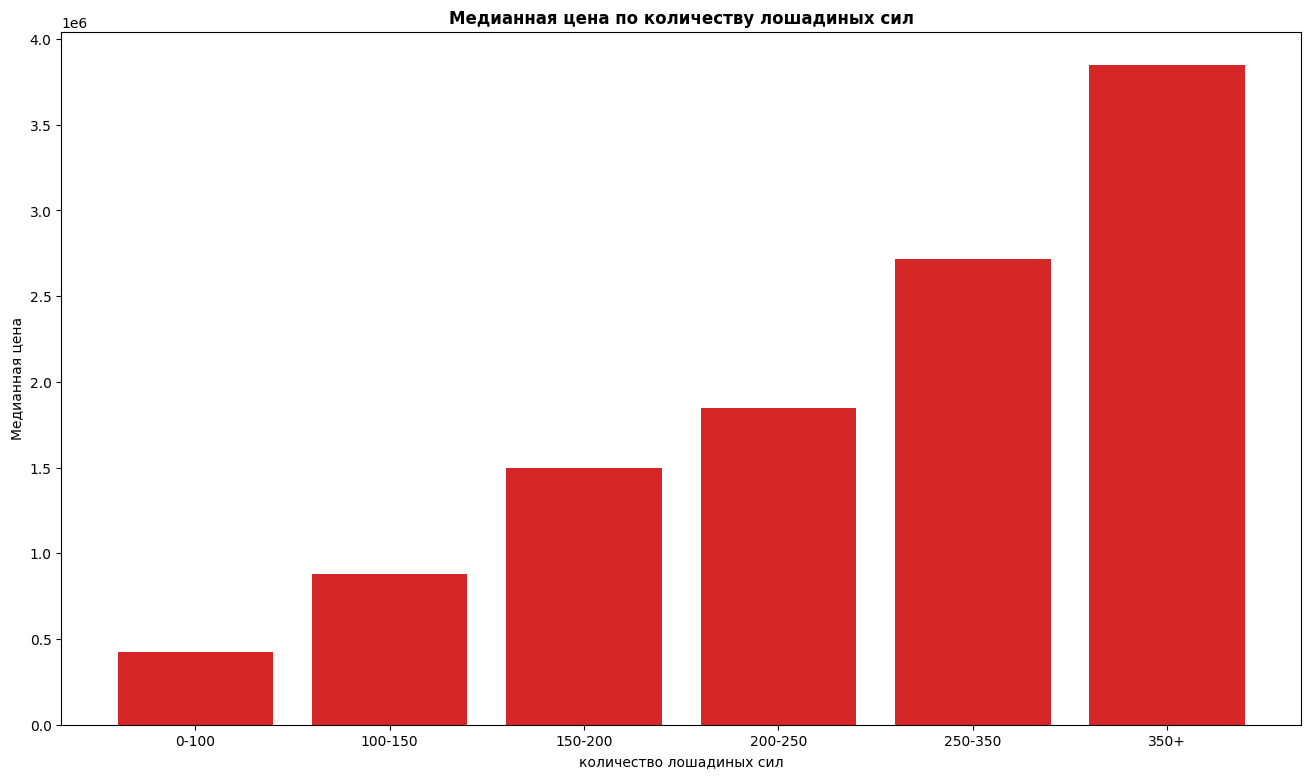

In [ ]:
plt.figure(figsize=(16, 9))
plt.bar(hp_pivot.index, hp_pivot['price'],color = '#D62728')

plt.title("Медианная цена по количеству лошадиных сил",fontweight='bold')
plt.xlabel('количество лошадиных сил')
plt.ylabel('Медианная цена')

вывод каой-то сильнее машина, плати дороже

#!!!tip_corobka доделать после фулл еда и разобраться что это ваще такое

In [ ]:
transmission_pivot = pd.pivot_table(df, values='price',index='transmission',aggfunc='median')
transmission_pivot

,price
transmission,
АКПП,1300000.0
автомат,1429000.0
вариатор,1394500.0
механика,548000.0
робот,1050000.0


<Axes: xlabel='transmission', ylabel='price'>

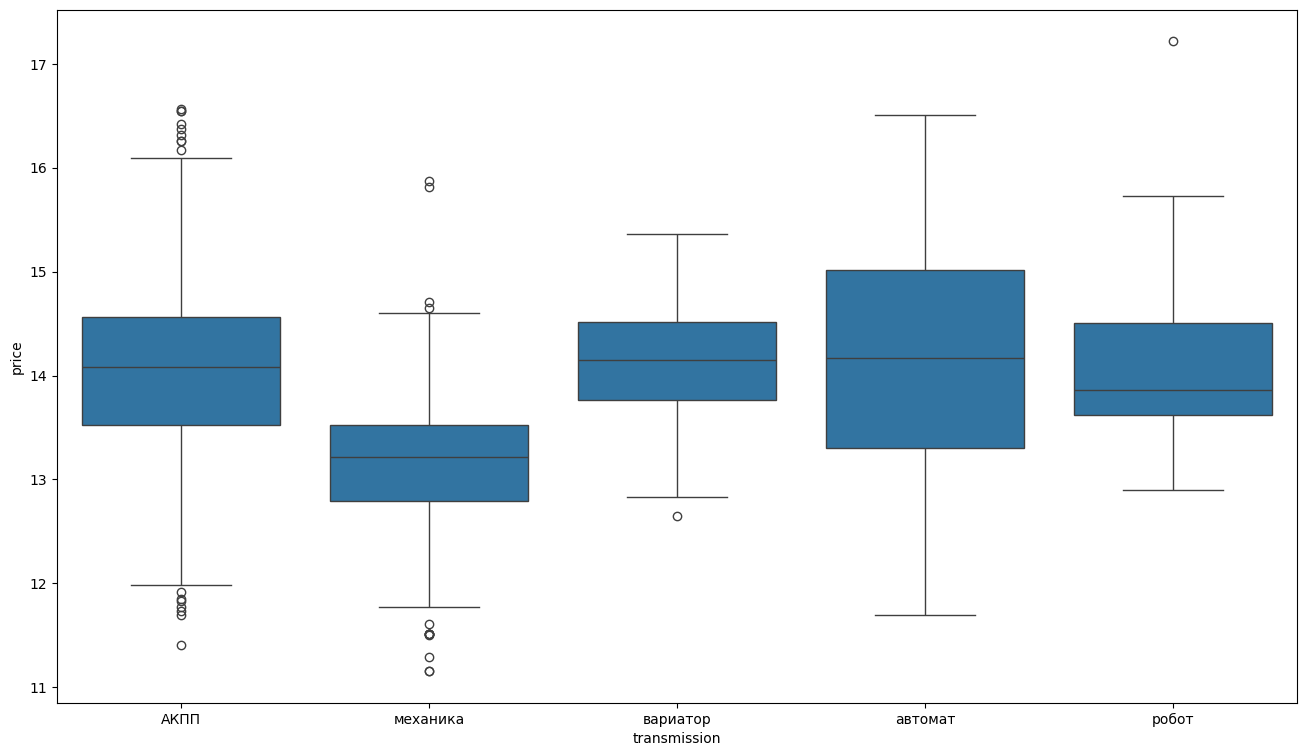

In [ ]:
plt.figure(figsize=(16, 9))
sns.boxplot(data=df,x='transmission',y=np.log(df['price']))


#Страна производства

In [ ]:
df['manufacturer_country'].unique()

array(['MEXICO', 'UNITED STATES (USA)', 'SLOVAKIA', 'GERMANY', 'JAPAN',
       nan], dtype=object)

In [ ]:
manufacturer_country_pivot = pd.pivot_table(df, values='price',index='manufacturer_country',aggfunc='median')
manufacturer_country_pivot

,price
manufacturer_country,
GERMANY,1512500.0
JAPAN,900000.0
MEXICO,949000.0
SLOVAKIA,1295000.0
UNITED STATES (USA),750000.0


Text(0, 0.5, 'Медианная цена')

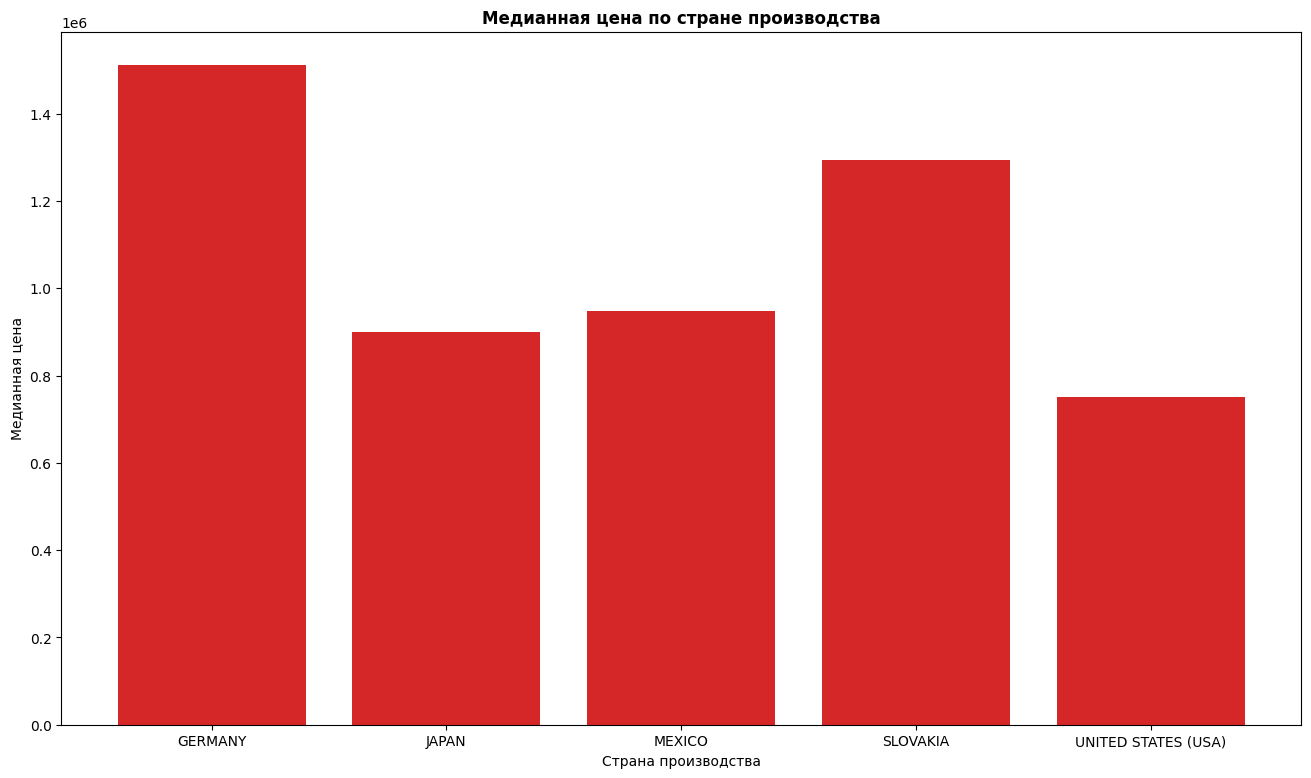

In [ ]:
plt.figure(figsize=(16, 9))
plt.bar(manufacturer_country_pivot.index, manufacturer_country_pivot['price'],color = '#D62728')

plt.title("Медианная цена по стране производства",fontweight='bold')
plt.xlabel('Страна производства')
plt.ylabel('Медианная цена')

выводы в

#Марка и безопасность

In [ ]:
problem_model_pivot = pd.pivot_table(df, values=['injuries','deaths','complaints_count','recalls_count'],index='make',aggfunc='median')
problem_model_pivot

,complaints_count,deaths,injuries,recalls_count
make,,,,
bmw,39.5,0.0,1.5,5.5
ford,391.0,1.0,23.0,2.0
honda,477.0,0.0,31.0,9.0
hyundai,144.5,0.0,12.0,4.0
kia,120.0,0.0,6.5,2.0
mazda,131.5,0.0,6.0,3.0
mitsubishi,45.0,0.0,3.0,6.0
nissan,87.0,0.0,4.0,3.0
toyota,251.0,0.0,29.0,4.0


Text(0.5, 1.0, 'Медианное количество отзывных компаний у марок машины')

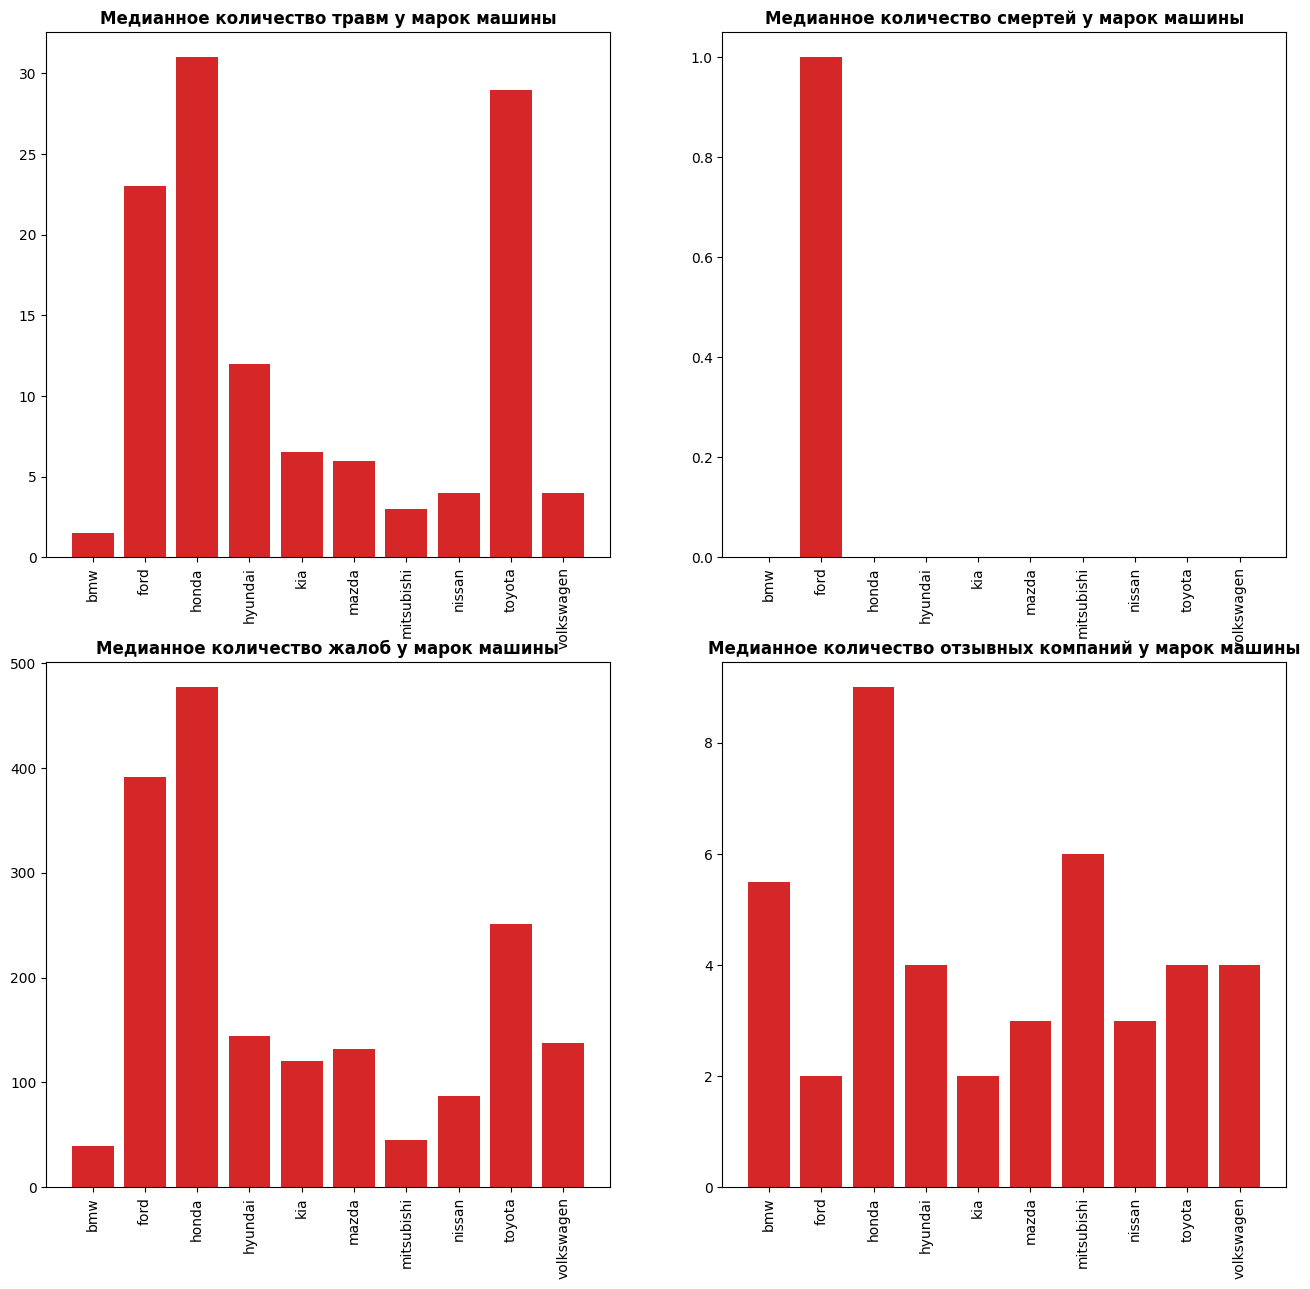

In [ ]:
plt.figure(figsize=(16, 15))
plt.subplot(2,2,1)
plt.bar(problem_model_pivot.index, problem_model_pivot['injuries'],color = '#D62728')
plt.xticks(rotation=90)
plt.title("Медианное количество травм у марок машины",fontweight='bold')
plt.subplot(2,2,2)
plt.bar(problem_model_pivot.index, problem_model_pivot['deaths'],color = '#D62728')
plt.xticks(rotation=90)
plt.title("Медианное количество смертей у марок машины",fontweight='bold')
plt.subplot(2,2,3)
plt.bar(problem_model_pivot.index, problem_model_pivot['complaints_count'],color = '#D62728')
plt.xticks(rotation=90)
plt.title("Медианное количество жалоб у марок машины",fontweight='bold')
plt.subplot(2,2,4)
plt.bar(problem_model_pivot.index, problem_model_pivot['recalls_count'],color = '#D62728')
plt.xticks(rotation=90)
plt.title("Медианное количество отзывных компаний у марок машины",fontweight='bold')

Выводы

# Год и безопасность

In [ ]:
problem_year_pivot = pd.pivot_table(df, values=['injuries','deaths','complaints_count','recalls_count'],index='year',aggfunc='median')
problem_year_pivot

,complaints_count,deaths,injuries,recalls_count
year,,,,
1983,8.0,0.0,0.0,1.0
1987,19.0,0.0,3.0,4.0
1989,20.0,0.0,1.0,1.0
1990,148.0,0.0,9.0,2.0
1991,29.0,0.0,0.0,1.0
1992,106.0,0.0,20.0,2.0
1993,152.0,1.0,38.0,6.0
1994,202.0,1.0,57.0,8.0
1995,169.0,0.0,36.0,5.0


Text(0.5, 1.0, 'Медианное количество отзывных компаний по году')

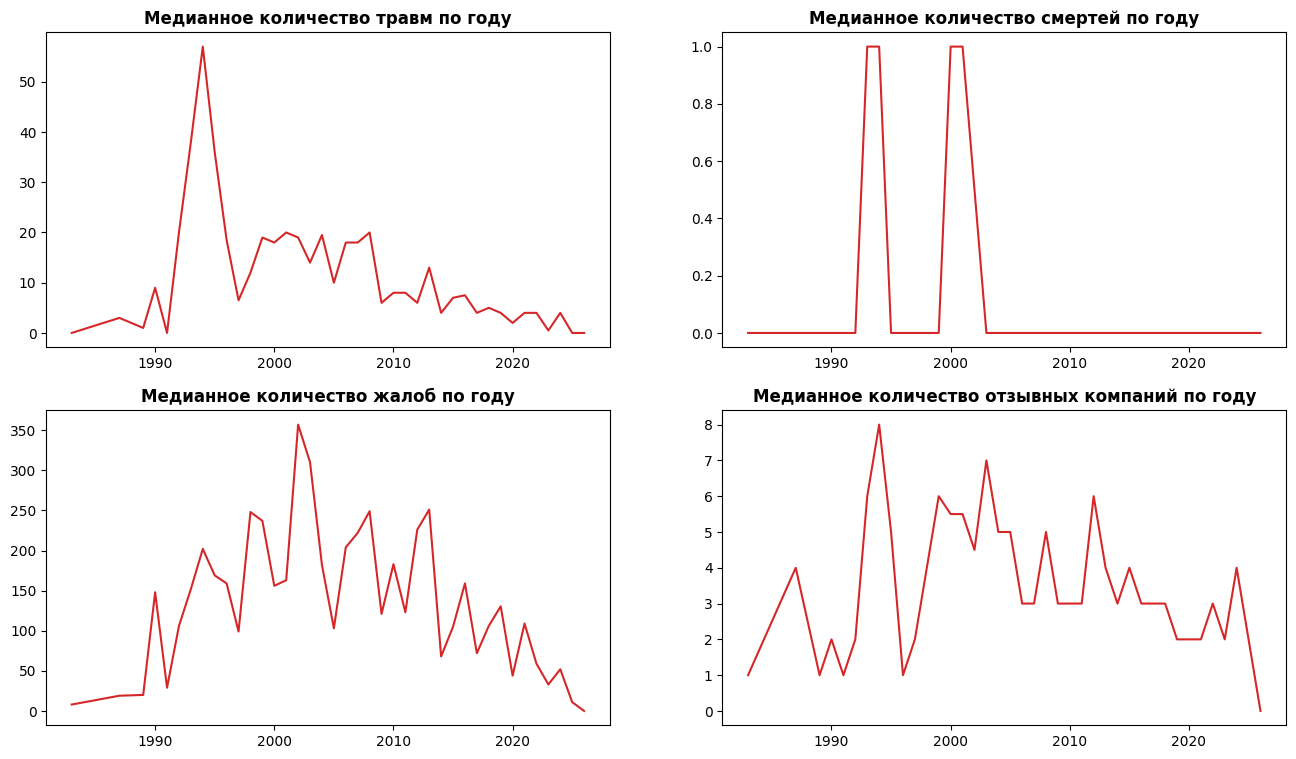

In [ ]:
plt.figure(figsize=(16, 9))
plt.subplot(2,2,1)
plt.plot(problem_year_pivot.index, problem_year_pivot['injuries'],color = '#D62728')
plt.title("Медианное количество травм по году",fontweight='bold')
plt.subplot(2,2,2)
plt.plot(problem_year_pivot.index, problem_year_pivot['deaths'],color = '#D62728')
plt.title("Медианное количество смертей по году",fontweight='bold')
plt.subplot(2,2,3)
plt.plot(problem_year_pivot.index, problem_year_pivot['complaints_count'],color = '#D62728')
plt.title("Медианное количество жалоб по году",fontweight='bold')
plt.subplot(2,2,4)
plt.plot(problem_year_pivot.index, problem_year_pivot['recalls_count'],color = '#D62728')
plt.title("Медианное количество отзывных компаний по году",fontweight='bold')

# Страна производителя и безопасность

In [ ]:
problem_country_pivot = pd.pivot_table(df, values=['injuries','deaths','complaints_count','recalls_count'],index='manufacturer_country',aggfunc='median')
problem_country_pivot

,complaints_count,deaths,injuries,recalls_count
manufacturer_country,,,,
GERMANY,98.5,0.0,3.0,4.0
JAPAN,131.5,0.0,6.0,3.0
MEXICO,133.0,0.0,9.0,4.0
SLOVAKIA,120.0,0.0,6.5,2.0
UNITED STATES (USA),231.0,0.0,19.0,5.0


Text(0.5, 1.0, 'Медианное количество отзывных компаний по стране производства')

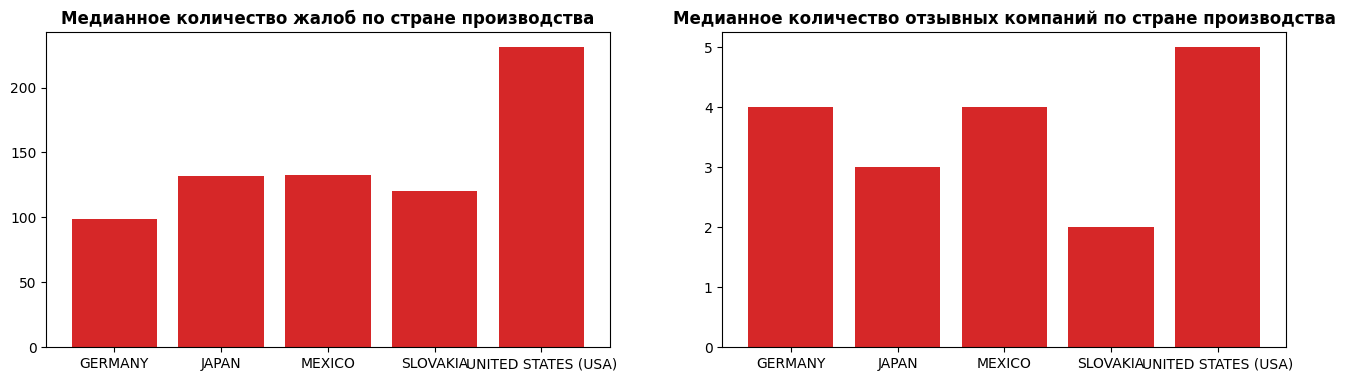

In [ ]:
plt.figure(figsize=(16, 9))
plt.subplot(2,2,1)
plt.bar(problem_country_pivot.index, problem_country_pivot['complaints_count'],color = '#D62728')
plt.title("Медианное количество жалоб по стране производства",fontweight='bold')
plt.subplot(2,2,2)
plt.bar(problem_country_pivot.index, problem_country_pivot['recalls_count'],color = '#D62728')
plt.title("Медианное количество отзывных компаний по стране производства",fontweight='bold')


**ВЫВООООД**

#Тип кузова и безопасность

In [ ]:
problem_body_pivot = pd.pivot_table(df, values=['has_crash','has_fire'],index='body',aggfunc='median')
problem_body_pivot

,has_crash,has_fire
body,,
джип/suv 5 дв.,9.5,8.0
купе,3.0,1.0
лифтбек,12.0,2.0
открытый,1.5,0.5
седан,14.0,3.0
универсал,22.0,6.0
хэтчбек 3 дв.,22.0,2.0
хэтчбек 5 дв.,22.0,3.0


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'джип/suv 5 дв.'),
  Text(1, 0, 'купе'),
  Text(2, 0, 'лифтбек'),
  Text(3, 0, 'открытый'),
  Text(4, 0, 'седан'),
  Text(5, 0, 'универсал'),
  Text(6, 0, 'хэтчбек 3 дв.'),
  Text(7, 0, 'хэтчбек 5 дв.')])

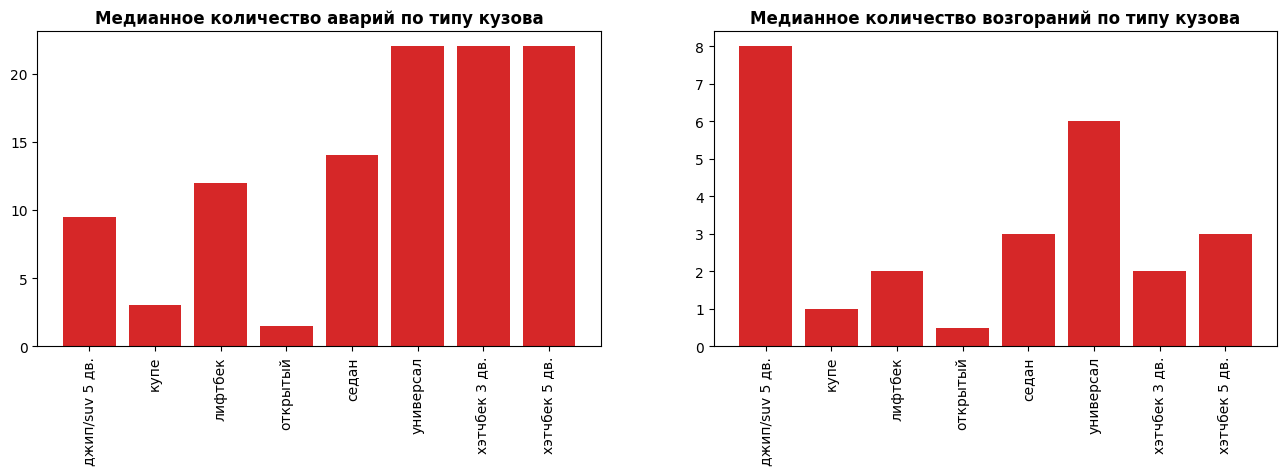

In [ ]:
plt.figure(figsize=(16, 9))
plt.subplot(2,2,1)
plt.bar(problem_body_pivot.index, problem_body_pivot['has_crash'],color = '#D62728')
plt.title("Медианное количество аварий по типу кузова",fontweight='bold')
plt.xticks(rotation=90)
plt.subplot(2,2,2)
plt.bar(problem_body_pivot.index, problem_body_pivot['has_fire'],color = '#D62728')
plt.title("Медианное количество возгораний по типу кузова",fontweight='bold')
plt.xticks(rotation=90)

**VYVOD**

#!!!цена и безопасность доделать

In [ ]:
df['problem_score'] = (df['complaints_count'] + df['recalls_count'])
df['problem_score']

,problem_score
0,225
1,367
2,91
3,33
4,187
...,...
1462,235
1463,47
1464,69
1465,33


обьяснить почему обьединила тут

In [ ]:
df['problem_group'] = pd.cut(df['problem_score'], bins=[0, 1, 10, 50, 1000],labels=['0', '1-10', '10-50', '50+'], right=False) #right=False,не вкл правую графницу, это для "0"

про right=False - тут https://docs-python.ru/packages/modul-pandas-analiz-dannykh-python/funktsiia-cut/

In [ ]:
problem_price_pivot = pd.pivot_table(df,values='price',index='problem_group',aggfunc='median')
problem_price_pivot

/tmp/ipykernel_9282/609196258.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  problem_price_pivot = pd.pivot_table(df,values='price',index='problem_group',aggfunc='median')


,price
problem_group,
0,1620000.0
1-10,2069000.0
10-50,1245000.0
50+,919000.0


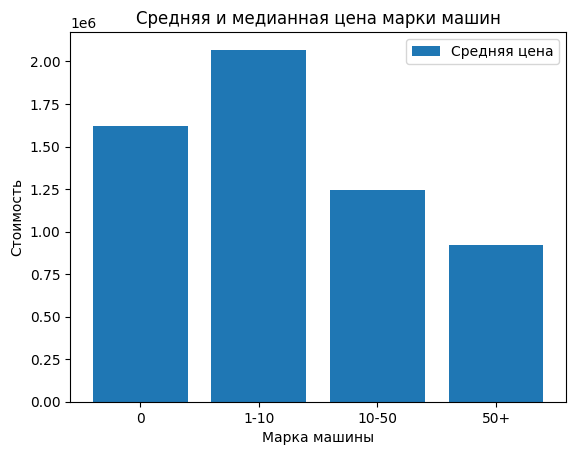

In [ ]:
plt.bar(problem_price_pivot.index, problem_price_pivot['price'])


plt.title("Средняя и медианная цена марки машин")
plt.xlabel('Марка машины')
plt.ylabel('Стоимость')
plt.legend(['Средняя цена'])